# KMNIST Data Exploration

Visualisations for the report's data presentation section.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.load('kmnist-train-imgs.npz')['arr_0']
y_train = np.load('kmnist-train-labels.npz')['arr_0']
x_test = np.load('kmnist-test-imgs.npz')['arr_0']
y_test = np.load('kmnist-test-labels.npz')['arr_0']

print(f'Training: {x_train.shape}, Labels: {y_train.shape}')
print(f'Testing:  {x_test.shape}, Labels: {y_test.shape}')
print(f'Classes:  {np.unique(y_train)}')
print(f'Pixel range: [{x_train.min()}, {x_train.max()}]')

Training: (60000, 28, 28), Labels: (60000,)
Testing:  (10000, 28, 28), Labels: (10000,)
Classes:  [0 1 2 3 4 5 6 7 8 9]
Pixel range: [0, 255]


## 1. Sample Images per Class

Two random samples from each of the 10 classes.

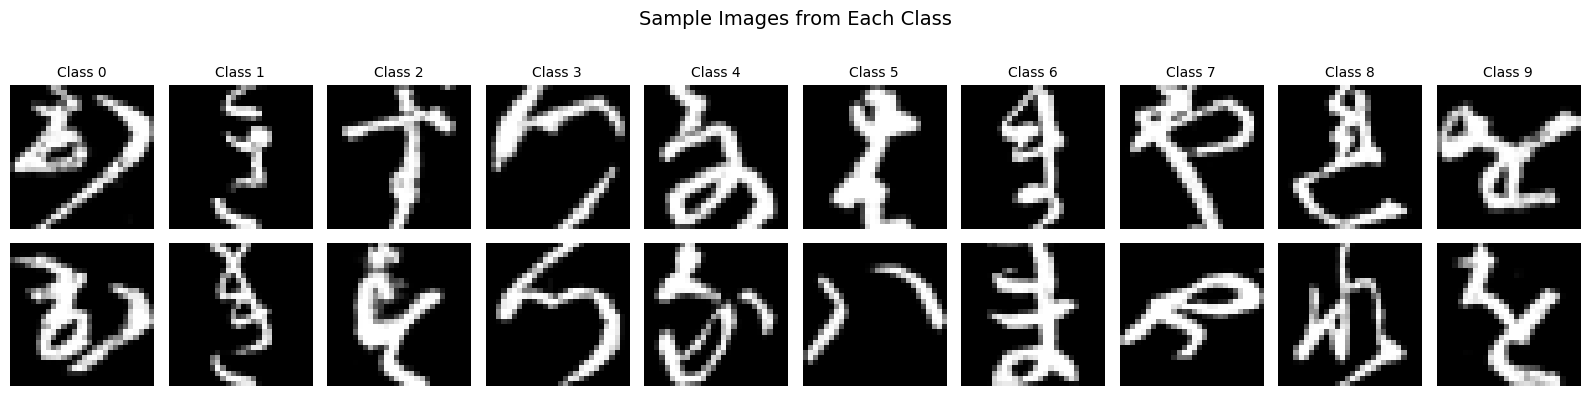

Saved: report_sample_images.png


In [2]:
# Sample image grid: 2 rows per class, 10 columns
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('Sample Images from Each Class', fontsize=14, y=1.02)

for cls in range(10):
    indices = np.where(y_train == cls)[0]
    samples = np.random.choice(indices, 2, replace=False)
    for row in range(2):
        axes[row, cls].imshow(x_train[samples[row]], cmap='gray')
        axes[row, cls].axis('off')
        if row == 0:
            axes[row, cls].set_title(f'Class {cls}', fontsize=10)

plt.tight_layout()
plt.savefig('report_sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: report_sample_images.png')

## 2. Class Distribution

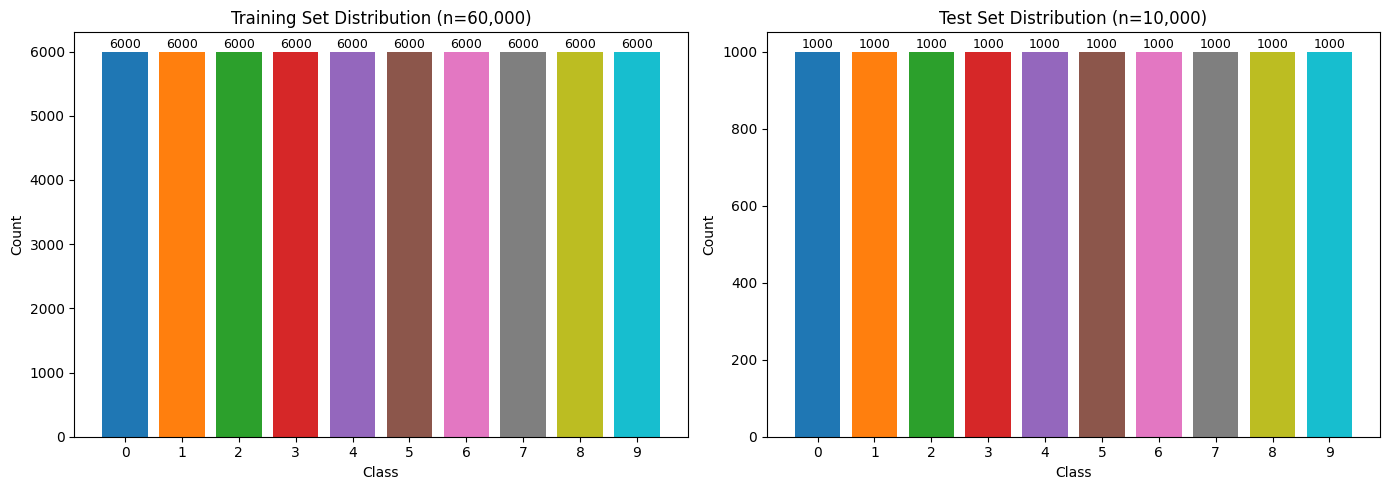

Saved: report_class_distribution.png


In [3]:
# Class distribution bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

classes, train_counts = np.unique(y_train, return_counts=True)
_, test_counts = np.unique(y_test, return_counts=True)

bar_colors = plt.cm.tab10(np.linspace(0, 1, 10))

ax1.bar(classes, train_counts, color=bar_colors)
ax1.set_xlabel('Class'); ax1.set_ylabel('Count')
ax1.set_title(f'Training Set Distribution (n={len(y_train):,})')
ax1.set_xticks(range(10))
for i, v in enumerate(train_counts):
    ax1.text(i, v + 50, str(v), ha='center', fontsize=9)

ax2.bar(classes, test_counts, color=bar_colors)
ax2.set_xlabel('Class'); ax2.set_ylabel('Count')
ax2.set_title(f'Test Set Distribution (n={len(y_test):,})')
ax2.set_xticks(range(10))
for i, v in enumerate(test_counts):
    ax2.text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('report_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: report_class_distribution.png')

## 3. Pixel Intensity Distribution

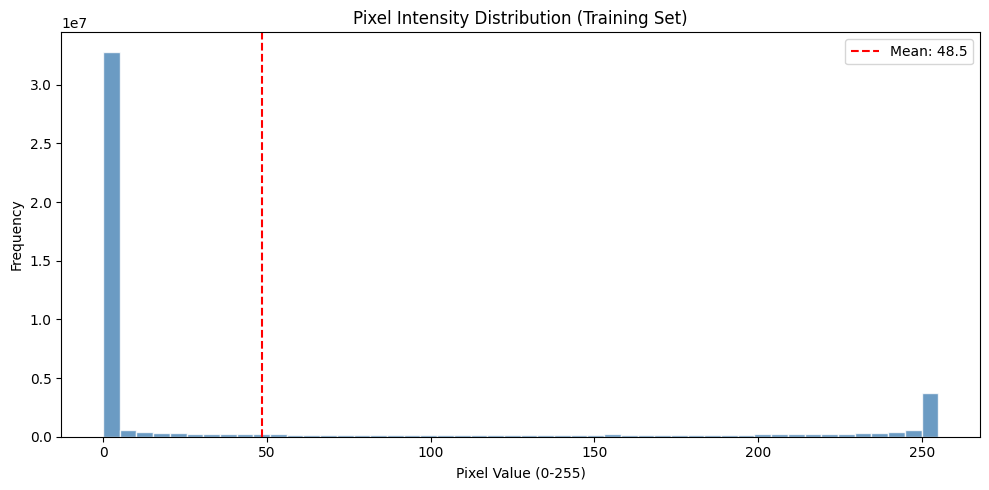

Saved: report_pixel_distribution.png


In [4]:
# Pixel intensity histogram
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(x_train.flatten(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Pixel Value (0-255)'); ax.set_ylabel('Frequency')
ax.set_title('Pixel Intensity Distribution (Training Set)')
ax.axvline(x=x_train.flatten().mean(), color='red', linestyle='--', label=f'Mean: {x_train.flatten().mean():.1f}')
ax.legend()
plt.tight_layout()
plt.savefig('report_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: report_pixel_distribution.png')

## 4. Average Image per Class

Shows the mean pixel pattern for each class — highlights which classes share similar visual features.

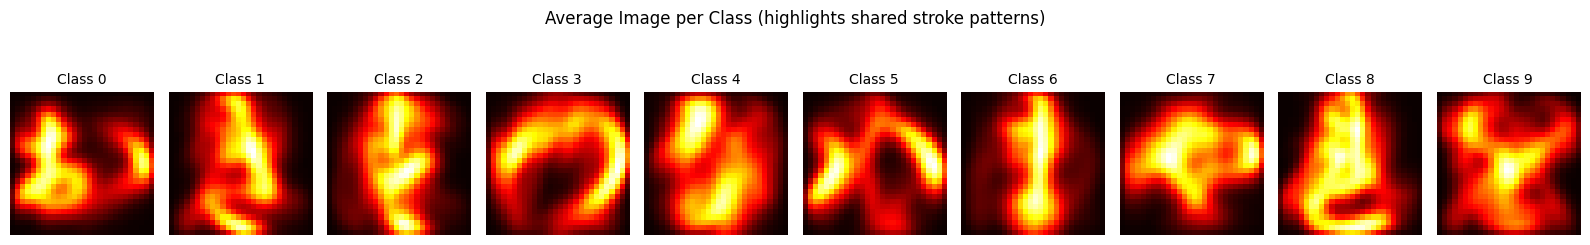

Saved: report_avg_class_images.png


In [5]:
# Average image per class
fig, axes = plt.subplots(1, 10, figsize=(16, 2.5))
fig.suptitle('Average Image per Class (highlights shared stroke patterns)', fontsize=12, y=1.05)

for cls in range(10):
    avg = x_train[y_train == cls].mean(axis=0)
    axes[cls].imshow(avg, cmap='hot')
    axes[cls].set_title(f'Class {cls}', fontsize=10)
    axes[cls].axis('off')

plt.tight_layout()
plt.savefig('report_avg_class_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: report_avg_class_images.png')

## 5. Intra-class Variation

Shows 10 random samples from 3 classes to illustrate handwriting variation within a single class.

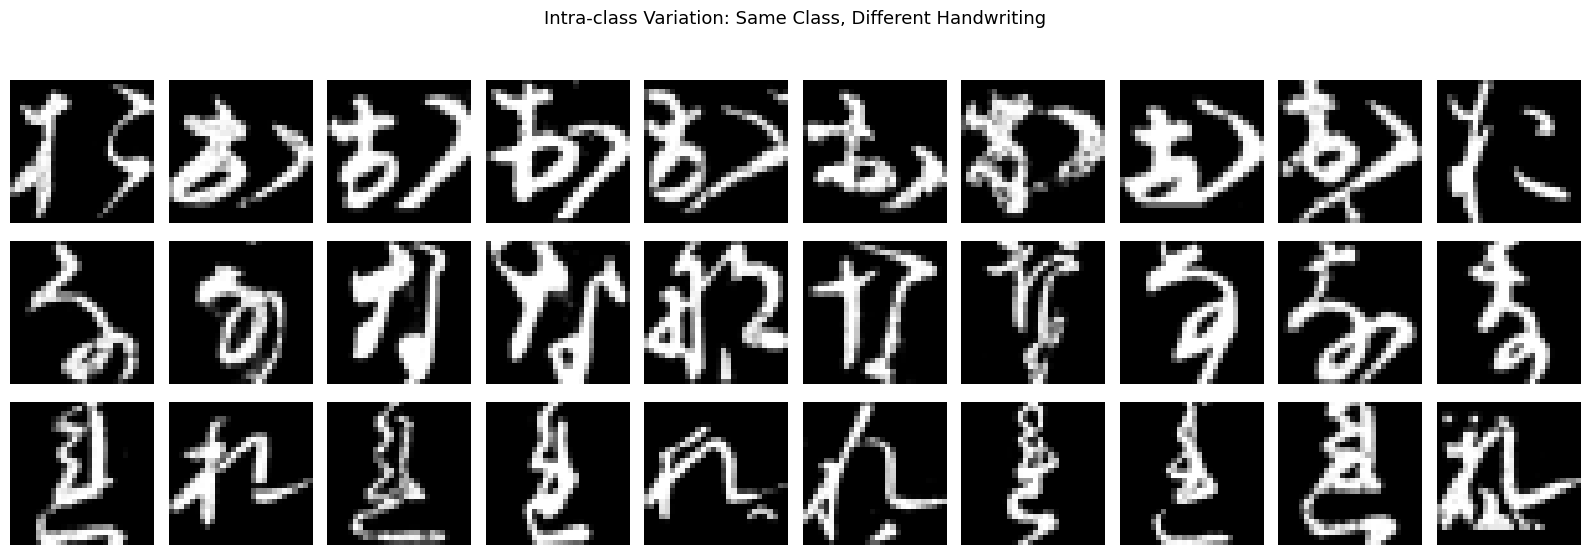

Saved: report_intra_class_variation.png


In [6]:
# Intra-class variation for 3 selected classes
selected_classes = [0, 4, 8]
fig, axes = plt.subplots(3, 10, figsize=(16, 5.5))
fig.suptitle('Intra-class Variation: Same Class, Different Handwriting', fontsize=13, y=1.02)

for row, cls in enumerate(selected_classes):
    indices = np.where(y_train == cls)[0]
    samples = np.random.choice(indices, 10, replace=False)
    for col in range(10):
        axes[row, col].imshow(x_train[samples[col]], cmap='gray')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'Class {cls}', fontsize=11, rotation=0, labelpad=40)

plt.tight_layout()
plt.savefig('report_intra_class_variation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: report_intra_class_variation.png')